## Cài đặt và import thư viện

In [1]:
!pip -q install pandas numpy scikit-learn matplotlib seaborn tensorflow

In [2]:
import re
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix
)

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.layers import (
    Input, Embedding, Bidirectional, LSTM, Dense, Dropout,
    GlobalMaxPooling1D, Layer
)
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.19.0


## Kiểm tra dữ liệu

In [3]:
df = pd.read_csv("/content/drive/MyDrive/dataset_dl/enron_spam_data.csv")
df.head()
print(df.shape)
print(df.columns)
print(df.isnull().sum())
df.sample(5)

(33716, 5)
Index(['Unnamed: 0', 'Subject', 'Message', 'Spam/Ham', 'Date'], dtype='object')
Unnamed: 0     0
Subject        0
Message       52
Spam/Ham       0
Date           0
dtype: int64


,Unnamed: 0,Subject,Message,Spam/Ham,Date
19307,19307,start date : 2 / 6 / 02 ; hourahead hour : 24 ;,start date : 2 / 6 / 02 ; hourahead hour : 24 ...,spam,2004-07-09
5247,5247,re : natural gas storage item,vince -\nsomething very interesting about natu...,ham,2000-01-06
26267,26267,transfers from ees,attached is the latest version of the cost cen...,spam,2005-07-02
20680,20680,start date : 2 / 6 / 02 ; hourahead hour : 24 ;,start date : 2 / 6 / 02 ; hourahead hour : 24 ...,spam,2004-12-12
4687,4687,re : tenaska iv,i tried calling you this am but your phone rol...,spam,2005-01-26


In [4]:
# đổi tên cột spam/ham sang label
# Ví dụ đổi tên cột nếu cần
rename_map = {}
for col in df.columns:
    c = col.lower().strip()
    if c == 'spam/ham':
        rename_map[col] = 'label'
    elif c == 'spam_ham':
        rename_map[col] = 'label'

df = df.rename(columns=rename_map)
print(df.columns)

Index(['Unnamed: 0', 'Subject', 'Message', 'label', 'Date'], dtype='object')


## Tiền xử lý dữ liệu

In [5]:
# Xử lý thiếu dữ liệu
df['Subject'] = df['Subject'].fillna('')
df['Message'] = df['Message'].fillna('')
if 'Date' in df.columns:
    df['Date'] = df['Date'].fillna('')

# Gộp subject + message
df['text'] = df['Subject'].astype(str) + " " + df['Message'].astype(str)

# Chuẩn hóa label về 0/1
def encode_label(x):
    x = str(x).strip().lower()
    if x in ['spam', '1', 'yes', 'true']:
        return 1
    return 0

df['label'] = df['label'].apply(encode_label)

print(df[['text', 'label']].head())
print(df['label'].value_counts())

                                                text  label
0                      christmas tree farm pictures       0
1  vastar resources , inc . gary , production fro...      0
2  calpine daily gas nomination - calpine daily g...      0
3  re : issue fyi - see note below - already done...      0
4  meter 7268 nov allocation fyi .\n- - - - - - -...      0
label
1    17171
0    16545
Name: count, dtype: int64


## Làm sạch văn bản

In [6]:
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'http\S+|www\S+', ' URL ', text)
    text = re.sub(r'\S+@\S+', ' EMAIL ', text)
    text = re.sub(r'\d+', ' NUM ', text)
    text = re.sub(r'[^a-z\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df['clean_text'] = df['text'].apply(clean_text)
df[['text', 'clean_text']].head()

,text,clean_text
0,christmas tree farm pictures,christmas tree farm pictures
1,"vastar resources , inc . gary , production fro...",vastar resources inc gary production from the ...
2,calpine daily gas nomination - calpine daily g...,calpine daily gas nomination calpine daily gas...
3,re : issue fyi - see note below - already done...,re issue fyi see note below already done stell...
4,meter 7268 nov allocation fyi .\n- - - - - - -...,meter nov allocation fyi forwarded by lauri a ...


## Chia tập train/validation/test

In [7]:
X = df['clean_text'].values
y = df['label'].values

# train 70%, val 15%, test 15%
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp
)

print("Train:", len(X_train))
print("Val:", len(X_val))
print("Test:", len(X_test))

Train: 23601
Val: 5057
Test: 5058


## Tokenizer và padding

In [8]:
MAX_VOCAB = 20000
MAX_LEN = 200
EMBED_DIM = 128

tokenizer = Tokenizer(num_words=MAX_VOCAB, oov_token="<OOV>")
tokenizer.fit_on_texts(X_train)

def encode_text(texts):
    seqs = tokenizer.texts_to_sequences(texts)
    pads = pad_sequences(seqs, maxlen=MAX_LEN, padding='post', truncating='post')
    return pads

X_train_pad = encode_text(X_train)
X_val_pad = encode_text(X_val)
X_test_pad = encode_text(X_test)

print(X_train_pad.shape, X_val_pad.shape, X_test_pad.shape)

(23601, 200) (5057, 200) (5058, 200)


## Hàm đánh giá

In [9]:
def evaluate_model(model, X_test, y_test, threshold=0.5):
    y_prob = model.predict(X_test, verbose=0).ravel()
    y_pred = (y_prob >= threshold).astype(int)

    acc = accuracy_score(y_test, y_pred)
    pre = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    print("Accuracy :", round(acc, 4))
    print("Precision:", round(pre, 4))
    print("Recall   :", round(rec, 4))
    print("F1-score :", round(f1, 4))
    print("\nClassification Report:\n")
    print(classification_report(y_test, y_pred, digits=4))

    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title("Confusion Matrix")
    plt.show()

    return {
        'accuracy': acc,
        'precision': pre,
        'recall': rec,
        'f1': f1
    }

## Hàm vẽ learning curves

In [10]:
def plot_history(history, title="Training History"):
    plt.figure(figsize=(12,4))

    plt.subplot(1,2,1)
    plt.plot(history.history['loss'], label='train_loss')
    plt.plot(history.history['val_loss'], label='val_loss')
    plt.title(title + " - Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()

    plt.subplot(1,2,2)
    plt.plot(history.history['accuracy'], label='train_acc')
    plt.plot(history.history['val_accuracy'], label='val_acc')
    plt.title(title + " - Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()

    plt.show()

## Xây dựng model baseline: BiLSTM

In [11]:
def build_baseline_model(
    vocab_size=MAX_VOCAB,
    embed_dim=EMBED_DIM,
    max_len=MAX_LEN,
    lstm_units=64,
    dropout_rate=0.5,
    l2_lambda=0.0
):
    model = Sequential([
        Embedding(input_dim=vocab_size, output_dim=embed_dim),
        Bidirectional(LSTM(lstm_units, return_sequences=False)),
        Dropout(dropout_rate),
        Dense(64, activation='relu', kernel_regularizer=l2(l2_lambda)),
        Dropout(dropout_rate),
        Dense(1, activation='sigmoid')
    ])
    return model

## Custom Attention Layer

In [12]:
class AttentionLayer(Layer):
    def __init__(self, **kwargs):
        super(AttentionLayer, self).__init__(**kwargs)

    def build(self, input_shape):
        self.W = self.add_weight(
            name="att_weight",
            shape=(input_shape[-1], 1),
            initializer="normal"
        )
        self.b = self.add_weight(
            name="att_bias",
            shape=(input_shape[1], 1),
            initializer="zeros"
        )
        super(AttentionLayer, self).build(input_shape)

    def call(self, x):
        e = tf.keras.backend.tanh(tf.keras.backend.dot(x, self.W) + self.b)
        a = tf.keras.backend.softmax(e, axis=1)
        output = x * a
        return tf.keras.backend.sum(output, axis=1)

## Model nâng cao: BiLSTM + Attention

In [13]:
def build_attention_model(
    vocab_size=MAX_VOCAB,
    embed_dim=EMBED_DIM,
    max_len=MAX_LEN,
    lstm_units=64,
    dropout_rate=0.5,
    l2_lambda=0.0
):
    inputs = Input(shape=(max_len,))
    x = Embedding(input_dim=vocab_size, output_dim=embed_dim)(inputs)
    x = Bidirectional(LSTM(lstm_units, return_sequences=True))(x)
    x = AttentionLayer()(x)
    x = Dropout(dropout_rate)(x)
    x = Dense(64, activation='relu', kernel_regularizer=l2(l2_lambda))(x)
    x = Dropout(dropout_rate)(x)
    outputs = Dense(1, activation='sigmoid')(x)

    model = Model(inputs, outputs)
    return model

## Hàm compile/train model

In [14]:
def compile_and_train(
    model,
    optimizer,
    X_train, y_train,
    X_val, y_val,
    epochs=10,
    batch_size=64
):
    model.compile(
        loss='binary_crossentropy',
        optimizer=optimizer,
        metrics=['accuracy']
    )

    callbacks = [
        EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2)
    ]

    history = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=epochs,
        batch_size=batch_size,
        callbacks=callbacks,
        verbose=1
    )
    return history

## Baseline với Adam + Dropout

In [15]:
X = df['clean_text'].values
y = df['label'].values

# train 70%, val 15%, test 15%
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp
)

print("Train:", len(X_train))
print("Val:", len(X_val))
print("Test:", len(X_test))

Train: 23601
Val: 5057
Test: 5058


In [16]:
MAX_VOCAB = 20000
MAX_LEN = 200
EMBED_DIM = 128

tokenizer = Tokenizer(num_words=MAX_VOCAB, oov_token="<OOV>")
tokenizer.fit_on_texts(X_train)

def encode_text(texts):
    seqs = tokenizer.texts_to_sequences(texts)
    pads = pad_sequences(seqs, maxlen=MAX_LEN, padding='post', truncating='post')
    return pads

X_train_pad = encode_text(X_train)
X_val_pad = encode_text(X_val)
X_test_pad = encode_text(X_test)

print(X_train_pad.shape, X_val_pad.shape, X_test_pad.shape)

(23601, 200) (5057, 200) (5058, 200)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 200, 128)       │     2,560,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 128)            │        98,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,667,137 (10.17 MB)

 Trainable params: 2,667,137 (10.17 MB)

 Non-trainable params: 0 (0.00 B)

Trainable params: 2667137
Epoch 1/10
369/369 ━━━━━━━━━━━━━━━━━━━━ 14s 21ms/step - accuracy: 0.9768 - loss: 0.0833 - val_accuracy: 0.9812 - val_loss: 0.0725 - learning_rate: 0.0010
Epoch 2/10
369/369 ━━━━━━━━━━━━━━━━━━━━ 16s 21ms/step - accuracy: 0.9961 - loss: 0.0248 - val_accuracy: 0.9802 - val_loss: 0.0881 - learning_rate: 0.0010
Epoch 3/10
369/369 ━━━━━━━━━━━━━━━━━━━━ 8s 22ms/step - accuracy: 0.9967 - loss: 0.0123 - val_accuracy: 0.9994 - val_loss: 0.0058 - learning_rate: 0.0010
Epoch 4/10
369/369 ━━━━━━━━━━━━━━━━━━━━ 8s 22ms/step - accuracy: 0.9998 - loss: 0.0031 - val_accuracy: 0.9994 - val_loss: 0.0059 - learning_rate: 0.0010
Epoch 5/10
369/369 ━━━━━━━━━━━━━━━━━━━━ 7s 20ms/step - accuracy: 0.9998 - loss: 0.0025 - val_accuracy: 0.9994 - val_loss: 0.0064 - learning_rate: 0.0010
Epoch 6/10
369/369 ━━━━━━━━━━━━━━━━━━━━ 8s 23ms/step - accuracy: 0.9998 - loss: 0.0024 - val_accuracy: 0.9994 - val_loss: 0.0062 - learning_rate: 5.0000e-04


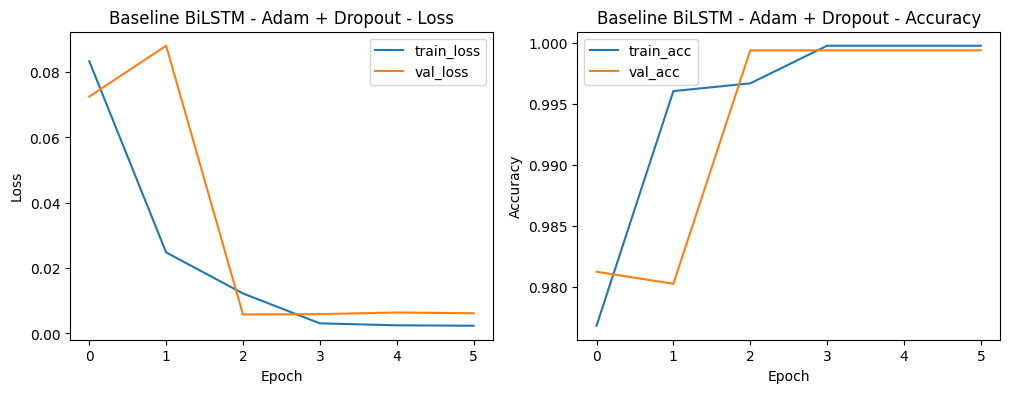

Accuracy : 0.9998
Precision: 0.9996
Recall   : 1.0
F1-score : 0.9998

Classification Report:

              precision    recall  f1-score   support

           0     1.0000    0.9996    0.9998      2482
           1     0.9996    1.0000    0.9998      2576

    accuracy                         0.9998      5058
   macro avg     0.9998    0.9998    0.9998      5058
weighted avg     0.9998    0.9998    0.9998      5058



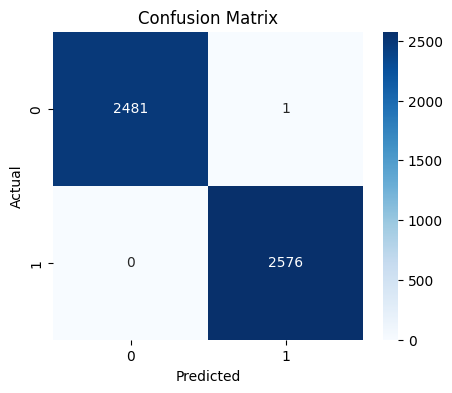

In [17]:
baseline_adam = build_baseline_model(dropout_rate=0.5, l2_lambda=0.0)
baseline_adam.build(input_shape=(None, MAX_LEN))
baseline_adam.summary()
print("Trainable params:", baseline_adam.count_params())

history_baseline_adam = compile_and_train(
    baseline_adam,
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    X_train=X_train_pad, y_train=y_train,
    X_val=X_val_pad, y_val=y_val,
    epochs=10,
    batch_size=64
)

plot_history(history_baseline_adam, "Baseline BiLSTM - Adam + Dropout")
baseline_adam_result = evaluate_model(baseline_adam, X_test_pad, y_test)

## Baseline với SGD + Dropout

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ (None, 200, 128)       │     2,560,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 128)            │        98,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,667,137 (10.17 MB)

 Trainable params: 2,667,137 (10.17 MB)

 Non-trainable params: 0 (0.00 B)

Trainable params: 2667137
Epoch 1/10
369/369 ━━━━━━━━━━━━━━━━━━━━ 13s 24ms/step - accuracy: 0.7962 - loss: 0.4515 - val_accuracy: 0.9583 - val_loss: 0.1763 - learning_rate: 0.0100
Epoch 2/10
369/369 ━━━━━━━━━━━━━━━━━━━━ 7s 20ms/step - accuracy: 0.9822 - loss: 0.0759 - val_accuracy: 0.9818 - val_loss: 0.0908 - learning_rate: 0.0100
Epoch 3/10
369/369 ━━━━━━━━━━━━━━━━━━━━ 7s 19ms/step - accuracy: 0.9949 - loss: 0.0293 - val_accuracy: 0.9990 - val_loss: 0.0064 - learning_rate: 0.0100
Epoch 4/10
369/369 ━━━━━━━━━━━━━━━━━━━━ 7s 20ms/step - accuracy: 0.9834 - loss: 0.0650 - val_accuracy: 0.9980 - val_loss: 0.0103 - learning_rate: 0.0100
Epoch 5/10
369/369 ━━━━━━━━━━━━━━━━━━━━ 7s 19ms/step - accuracy: 0.9989 - loss: 0.0091 - val_accuracy: 0.9992 - val_loss: 0.0050 - learning_rate: 0.0100
Epoch 6/10
369/369 ━━━━━━━━━━━━━━━━━━━━ 8s 22ms/step - accuracy: 0.9994 - loss: 0.0050 - val_accuracy: 0.9992 - val_loss: 0.0063 - learning_rate: 0.0100
Epoch 7/10
369/369 ━━━━━━━━━━━━━━━━━━━━ 7s 18ms/step - 

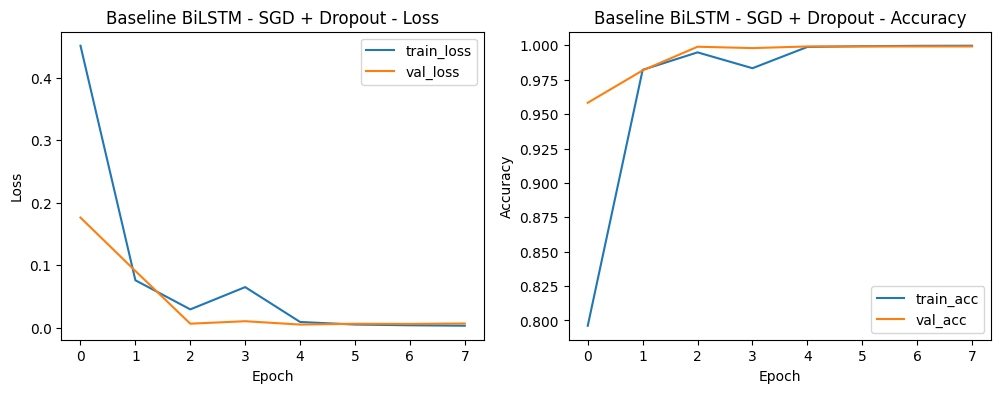

Accuracy : 0.9994
Precision: 0.9988
Recall   : 1.0
F1-score : 0.9994

Classification Report:

              precision    recall  f1-score   support

           0     1.0000    0.9988    0.9994      2482
           1     0.9988    1.0000    0.9994      2576

    accuracy                         0.9994      5058
   macro avg     0.9994    0.9994    0.9994      5058
weighted avg     0.9994    0.9994    0.9994      5058



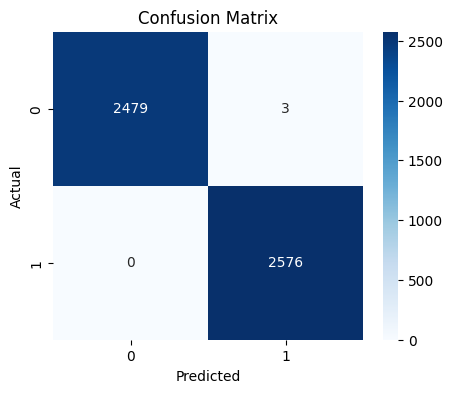

In [18]:
baseline_sgd = build_baseline_model(dropout_rate=0.5, l2_lambda=0.0)
baseline_sgd.build(input_shape=(None, MAX_LEN))
baseline_sgd.summary()
print("Trainable params:", baseline_sgd.count_params())

history_baseline_sgd = compile_and_train(
    baseline_sgd,
    optimizer=tf.keras.optimizers.SGD(learning_rate=1e-2, momentum=0.9),
    X_train=X_train_pad, y_train=y_train,
    X_val=X_val_pad, y_val=y_val,
    epochs=10,
    batch_size=64
)

plot_history(history_baseline_sgd, "Baseline BiLSTM - SGD + Dropout")
baseline_sgd_result = evaluate_model(baseline_sgd, X_test_pad, y_test)

## Baseline với Adam + L2 Weight Decay

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ (None, 200, 128)       │     2,560,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_2 (Bidirectional) │ (None, 128)            │        98,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,667,137 (10.17 MB)

 Trainable params: 2,667,137 (10.17 MB)

 Non-trainable params: 0 (0.00 B)

Trainable params: 2667137
Epoch 1/10
369/369 ━━━━━━━━━━━━━━━━━━━━ 15s 28ms/step - accuracy: 0.9888 - loss: 0.0478 - val_accuracy: 0.9984 - val_loss: 0.0149 - learning_rate: 0.0010
Epoch 2/10
369/369 ━━━━━━━━━━━━━━━━━━━━ 11s 30ms/step - accuracy: 0.9995 - loss: 0.0088 - val_accuracy: 0.9994 - val_loss: 0.0088 - learning_rate: 0.0010
Epoch 3/10
369/369 ━━━━━━━━━━━━━━━━━━━━ 21s 32ms/step - accuracy: 0.9997 - loss: 0.0058 - val_accuracy: 0.9994 - val_loss: 0.0079 - learning_rate: 0.0010
Epoch 4/10
369/369 ━━━━━━━━━━━━━━━━━━━━ 12s 31ms/step - accuracy: 0.9998 - loss: 0.0045 - val_accuracy: 0.9994 - val_loss: 0.0066 - learning_rate: 0.0010
Epoch 5/10
369/369 ━━━━━━━━━━━━━━━━━━━━ 8s 21ms/step - accuracy: 0.9998 - loss: 0.0038 - val_accuracy: 0.9994 - val_loss: 0.0071 - learning_rate: 0.0010
Epoch 6/10
369/369 ━━━━━━━━━━━━━━━━━━━━ 8s 23ms/step - accuracy: 0.9998 - loss: 0.0036 - val_accuracy: 0.9994 - val_loss: 0.0070 - learning_rate: 0.0010
Epoch 7/10
369/369 ━━━━━━━━━━━━━━━━━━━━ 8s 22ms/step

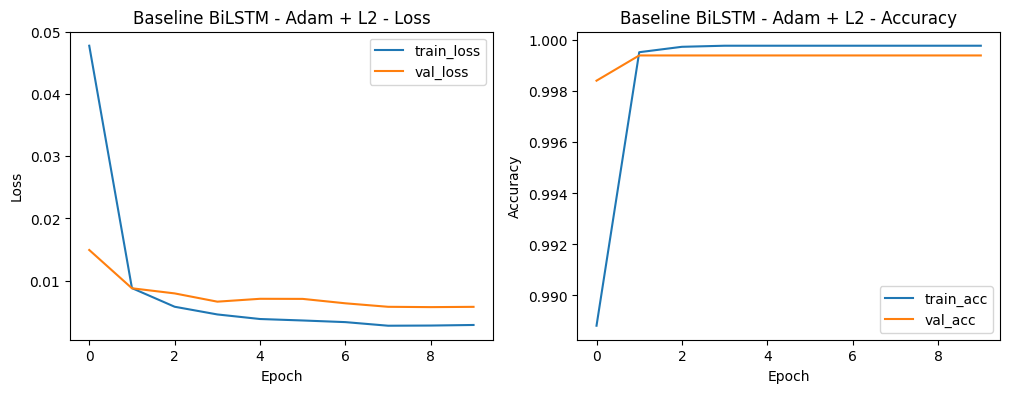

Accuracy : 0.9998
Precision: 0.9996
Recall   : 1.0
F1-score : 0.9998

Classification Report:

              precision    recall  f1-score   support

           0     1.0000    0.9996    0.9998      2482
           1     0.9996    1.0000    0.9998      2576

    accuracy                         0.9998      5058
   macro avg     0.9998    0.9998    0.9998      5058
weighted avg     0.9998    0.9998    0.9998      5058



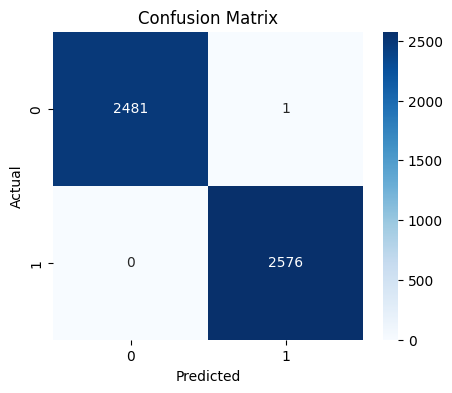

In [19]:
baseline_l2 = build_baseline_model(dropout_rate=0.3, l2_lambda=1e-4)
baseline_l2.build(input_shape=(None, MAX_LEN))
baseline_l2.summary()
print("Trainable params:", baseline_l2.count_params())

history_baseline_l2 = compile_and_train(
    baseline_l2,
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    X_train=X_train_pad, y_train=y_train,
    X_val=X_val_pad, y_val=y_val,
    epochs=10,
    batch_size=64
)

plot_history(history_baseline_l2, "Baseline BiLSTM - Adam + L2")
baseline_l2_result = evaluate_model(baseline_l2, X_test_pad, y_test)

## Attention model với Adam + Dropout + L2

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 200)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding_3 (Embedding)         │ (None, 200, 128)       │     2,560,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_3 (Bidirectional) │ (None, 200, 128)       │        98,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ attention_layer                 │ (None, 128)            │           328 │
│ (AttentionLayer)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,667,465 (10.18 MB)

 Trainable params: 2,667,465 (10.18 MB)

 Non-trainable params: 0 (0.00 B)

Trainable params: 2667465
Epoch 1/10
369/369 ━━━━━━━━━━━━━━━━━━━━ 20s 39ms/step - accuracy: 0.9771 - loss: 0.0584 - val_accuracy: 0.9992 - val_loss: 0.0115 - learning_rate: 0.0010
Epoch 2/10
369/369 ━━━━━━━━━━━━━━━━━━━━ 8s 22ms/step - accuracy: 0.9994 - loss: 0.0111 - val_accuracy: 0.9992 - val_loss: 0.0098 - learning_rate: 0.0010
Epoch 3/10
369/369 ━━━━━━━━━━━━━━━━━━━━ 9s 24ms/step - accuracy: 0.9994 - loss: 0.0088 - val_accuracy: 0.9992 - val_loss: 0.0081 - learning_rate: 0.0010
Epoch 4/10
369/369 ━━━━━━━━━━━━━━━━━━━━ 8s 21ms/step - accuracy: 0.9994 - loss: 0.0075 - val_accuracy: 0.9992 - val_loss: 0.0081 - learning_rate: 0.0010
Epoch 5/10
369/369 ━━━━━━━━━━━━━━━━━━━━ 9s 24ms/step - accuracy: 0.9995 - loss: 0.0062 - val_accuracy: 0.9992 - val_loss: 0.0079 - learning_rate: 0.0010
Epoch 6/10
369/369 ━━━━━━━━━━━━━━━━━━━━ 9s 25ms/step - accuracy: 0.9996 - loss: 0.0054 - val_accuracy: 0.9992 - val_loss: 0.0078 - learning_rate: 0.0010
Epoch 7/10
369/369 ━━━━━━━━━━━━━━━━━━━━ 8s 21ms/step - 

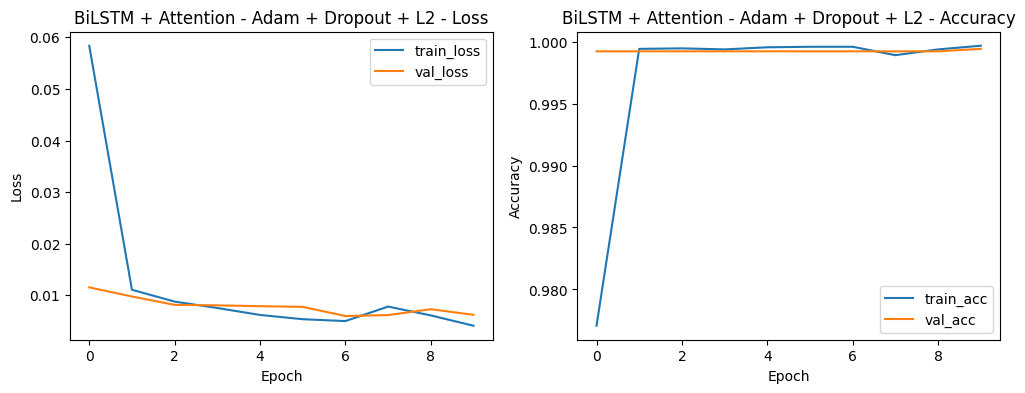

Accuracy : 0.9998
Precision: 0.9996
Recall   : 1.0
F1-score : 0.9998

Classification Report:

              precision    recall  f1-score   support

           0     1.0000    0.9996    0.9998      2482
           1     0.9996    1.0000    0.9998      2576

    accuracy                         0.9998      5058
   macro avg     0.9998    0.9998    0.9998      5058
weighted avg     0.9998    0.9998    0.9998      5058



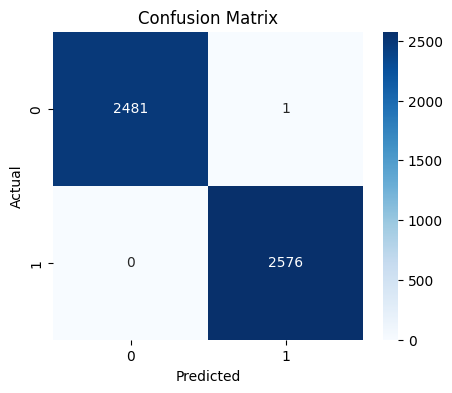

In [20]:
attention_model = build_attention_model(dropout_rate=0.5, l2_lambda=1e-4)
attention_model.build(input_shape=(None, MAX_LEN))
attention_model.summary()
print("Trainable params:", attention_model.count_params())

history_attention = compile_and_train(
    attention_model,
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    X_train=X_train_pad, y_train=y_train,
    X_val=X_val_pad, y_val=y_val,
    epochs=10,
    batch_size=64
)

plot_history(history_attention, "BiLSTM + Attention - Adam + Dropout + L2")
attention_result = evaluate_model(attention_model, X_test_pad, y_test)

## Bảng tổng hợp kết quả

In [21]:
results = pd.DataFrame([
    ["Baseline_BiLSTM_Adam_Dropout", baseline_adam.count_params(),
     baseline_adam_result['accuracy'], baseline_adam_result['precision'],
     baseline_adam_result['recall'], baseline_adam_result['f1']],

    ["Baseline_BiLSTM_SGD_Dropout", baseline_sgd.count_params(),
     baseline_sgd_result['accuracy'], baseline_sgd_result['precision'],
     baseline_sgd_result['recall'], baseline_sgd_result['f1']],

    ["Baseline_BiLSTM_Adam_L2", baseline_l2.count_params(),
     baseline_l2_result['accuracy'], baseline_l2_result['precision'],
     baseline_l2_result['recall'], baseline_l2_result['f1']],

    ["BiLSTM_Attention_Adam_Dropout_L2", attention_model.count_params(),
     attention_result['accuracy'], attention_result['precision'],
     attention_result['recall'], attention_result['f1']],
], columns=["Model", "Params", "Accuracy", "Precision", "Recall", "F1-score"])

results = results.sort_values(by="F1-score", ascending=False)
results

,Model,Params,Accuracy,Precision,Recall,F1-score
0,Baseline_BiLSTM_Adam_Dropout,2667137,0.999802,0.999612,1.0,0.999806
2,Baseline_BiLSTM_Adam_L2,2667137,0.999802,0.999612,1.0,0.999806
3,BiLSTM_Attention_Adam_Dropout_L2,2667465,0.999802,0.999612,1.0,0.999806
1,Baseline_BiLSTM_SGD_Dropout,2667137,0.999407,0.998837,1.0,0.999418


## Biểu đồ so sánh

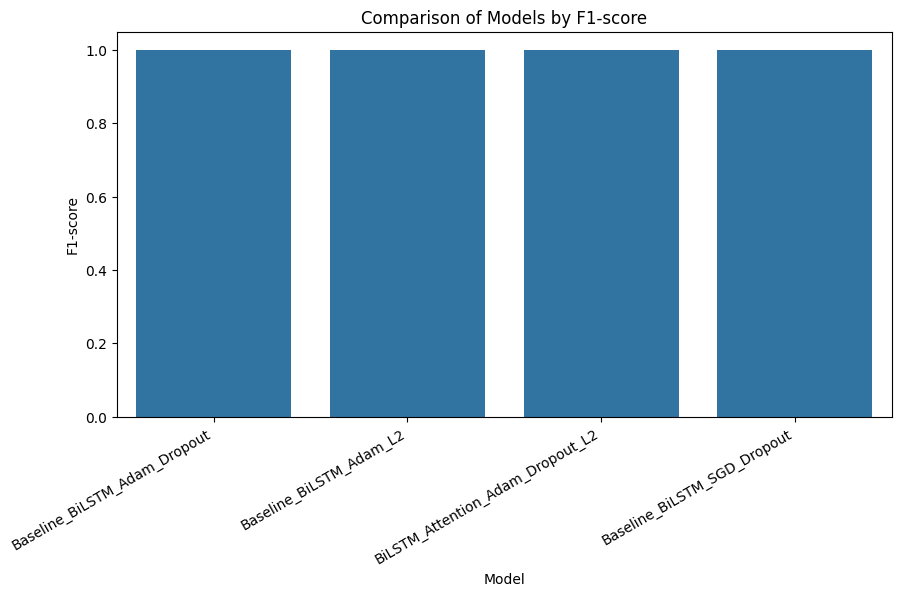

In [22]:
plt.figure(figsize=(10,5))
sns.barplot(data=results, x="Model", y="F1-score")
plt.xticks(rotation=30, ha='right')
plt.title("Comparison of Models by F1-score")
plt.show()

## Phân tích lỗi mẫu

In [23]:
def get_failure_cases(model, X_raw, X_pad, y_true, n=10):
    y_prob = model.predict(X_pad, verbose=0).ravel()
    y_pred = (y_prob >= 0.5).astype(int)

    errors = []
    for text, true_label, pred_label, prob in zip(X_raw, y_true, y_pred, y_prob):
        if true_label != pred_label:
            errors.append({
                "text": text[:500],
                "true": true_label,
                "pred": pred_label,
                "prob_spam": float(prob)
            })
    return pd.DataFrame(errors).head(n)

failure_df = get_failure_cases(attention_model, X_test, X_test_pad, y_test, n=10)
failure_df

,text,true,pred,prob_spam
0,start date hourahead hour start date hourahead...,0,1,0.99683
